# 01 · Data exploration (EDA)
**Owner:** Ivan Manzi· **Project:** Research-informed sequential models for GBV tweet classification

**Purpose.** Before any modelling we establish what the data looks like: structure, class balance, tweet length, vocabulary, social-media noise, and duplicates. Findings here justify the preprocessing, the choice of primary metric (macro-F1), the sequence lengths used by the neural models, and the shared train/validation split that *all* notebooks reuse.

**Rules followed.** Only the approved challenge data is used. Statistics are computed, not assumed. Labels are used only to *describe* the data (never to build model features). Raw tweets can contain graphic abuse, so this notebook prints **aggregate statistics and tokens only, no example tweets**.

**Outputs.** Tables → `results/metrics/eda_*.csv`, split → `results/metrics/split.csv`, figures → `results/figures/fig01…fig05`.

**Sections:** 1 Setup · 2 Dataset structure · 3 Class distribution · 4 Tweet length · 5 Vocabulary · 6 Social-media noise · 7 Duplicates · 8 Shared split · 9 Findings

## 1. Setup
Runs locally or in Google Colab. In Colab the cell clones the repo and installs requirements; you must then upload the Zindi zip into `data/` (Files panel) — see the error message from `load_raw()` if the data is missing.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/data-pipeline"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # running from notebooks/ locally -> move to the repo root so relative paths work
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, SEED, RESULTS_DIR
from src.data_loader import load_raw, make_split, duplicate_group_key, ID_COL, TEXT_COL, LABEL_COL
from src.plotting import save_fig
from src import eda

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)
METRICS = RESULTS_DIR / "metrics"
METRICS.mkdir(parents=True, exist_ok=True)
print("seed =", SEED, "| pandas", pd.__version__, "| numpy", np.__version__)

seed = 42 | pandas 3.0.6 | numpy 2.5.3


## 2. Dataset structure
Sizes, columns, missing values, ID uniqueness and duplicate tweets, for `Train.csv` and `Test.csv`. The test set has no labels, so it is used only for descriptive comparison (never for fitting anything).

In [3]:
train, test, sample = load_raw()
overview = eda.dataset_overview(train, test, TEXT_COL, LABEL_COL, ID_COL)
overview.to_csv(METRICS / "eda_dataset_overview.csv")
print("SampleSubmission columns:", list(sample.columns), "| rows:", len(sample))
overview

SampleSubmission columns: ['Tweet_ID', 'type'] | rows: 15581


,train,test
rows,39650,15581
columns,"Tweet_ID, tweet, type","Tweet_ID, tweet"
missing values (total),0,0
empty tweets,0,0
unique IDs,39650,15581
IDs unique?,True,True
duplicate tweets (rows beyond first),8,13
unique classes,5,n/a


## 3. Class distribution
The class balance decides whether accuracy alone is a meaningful metric or whether macro-averaged metrics are needed.

In [4]:
dist = eda.class_distribution(train, LABEL_COL)
dist.to_csv(METRICS / "eda_class_distribution.csv")
CLASS_ORDER = list(dist.index)  # largest -> smallest; reused for consistent plot ordering
majority_acc = dist["percent"].iloc[0]
print(f"Majority-class baseline accuracy: {majority_acc:.2f}%  (predicting '{CLASS_ORDER[0]}' for every tweet)")
dist

Majority-class baseline accuracy: 82.34%  (predicting 'sexual_violence' for every tweet)


,count,percent,imbalance_vs_largest
type,,,
sexual_violence,32648,82.34,1.0
Physical_violence,5946,15.00,5.5
emotional_violence,651,1.64,50.2
economic_violence,217,0.55,150.5
Harmful_Traditional_practice,188,0.47,173.7


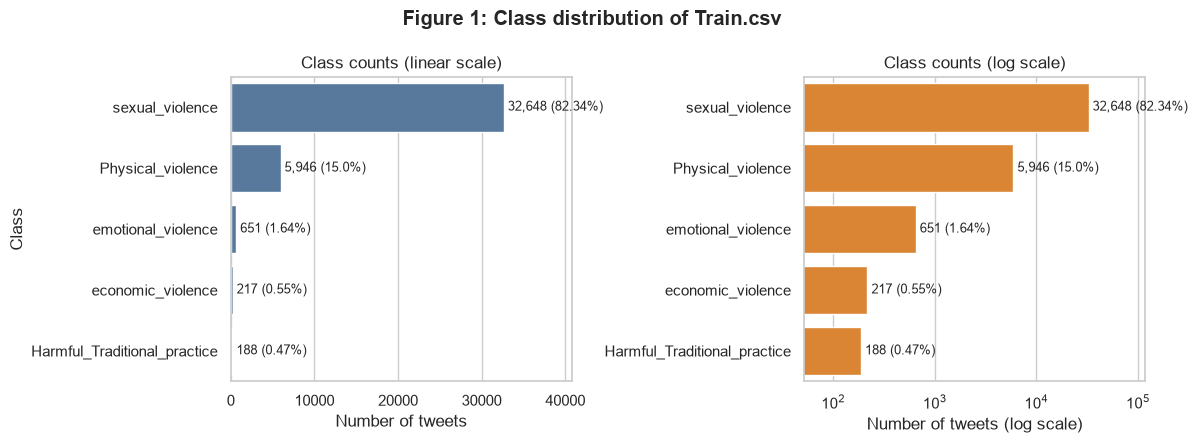

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=dist["count"].values, y=dist.index, ax=axes[0], color="#4C78A8")
axes[0].set_xlabel("Number of tweets"); axes[0].set_ylabel("Class")
axes[0].set_title("Class counts (linear scale)")
sns.barplot(x=dist["count"].values, y=dist.index, ax=axes[1], color="#F58518")
axes[1].set_xscale("log"); axes[1].set_xlabel("Number of tweets (log scale)"); axes[1].set_ylabel("")
axes[1].set_title("Class counts (log scale)")
for ax in axes:
    for p, (c, pct) in zip(ax.patches, zip(dist["count"], dist["percent"])):
        ax.text(p.get_width(), p.get_y() + p.get_height() / 2, f" {c:,} ({pct}%)", va="center", fontsize=9)
    ax.margins(x=0.25)
fig.suptitle("Figure 1: Class distribution of Train.csv", fontweight="bold")
fig.tight_layout(); save_fig(fig, "fig01_class_distribution"); plt.show()

## 4. Tweet length
Characters, whitespace-separated words and alphanumeric tokens per tweet. High percentiles of the token length guide the **maximum sequence length** used by the LSTM/CNN/TCN/Transformer (padding/truncation trade-off).

In [6]:
len_train = eda.length_features(train, TEXT_COL)
len_test = eda.length_features(test, TEXT_COL)
length_stats = pd.DataFrame({
    f"{name} · {unit}": eda.numeric_summary(df[unit])
    for name, df in [("train", len_train), ("test", len_test)] for unit in ["chars", "words", "tokens"]
}).T.round(2)
length_stats.to_csv(METRICS / "eda_length_stats.csv")
length_stats

,min,max,mean,median,std,p5,p25,p50,p75,p90,p95,p99
train · chars,10.0,308.0,199.40,225.0,76.63,61.0,133.0,225.0,270.0,279.0,280.0,286.0
train · words,2.0,68.0,38.89,43.0,15.15,12.0,26.0,43.0,52.0,56.0,58.0,61.0
train · tokens,3.0,70.0,38.87,43.0,15.27,11.0,26.0,43.0,52.0,56.0,58.0,61.0
test · chars,24.0,308.0,194.97,212.0,72.54,73.0,129.0,212.0,264.0,278.0,280.0,285.0
test · words,4.0,65.0,35.60,37.0,13.48,13.0,24.0,37.0,47.0,52.0,55.0,59.0
test · tokens,4.0,65.0,35.75,37.0,13.53,13.0,25.0,37.0,47.0,53.0,55.0,59.0


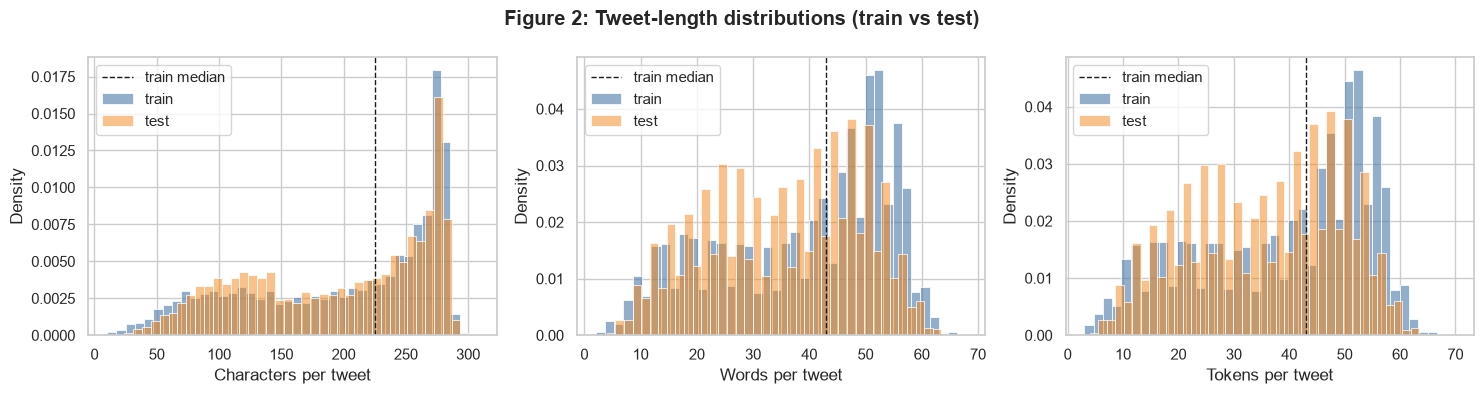

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, unit, xl in zip(axes, ["chars", "words", "tokens"], ["Characters per tweet", "Words per tweet", "Tokens per tweet"]):
    sns.histplot(len_train[unit], bins=40, stat="density", ax=ax, color="#4C78A8", label="train", alpha=0.6)
    sns.histplot(len_test[unit], bins=40, stat="density", ax=ax, color="#F58518", label="test", alpha=0.5)
    ax.axvline(len_train[unit].median(), color="k", ls="--", lw=1, label="train median")
    ax.set_xlabel(xl); ax.set_ylabel("Density"); ax.legend()
fig.suptitle("Figure 2: Tweet-length distributions (train vs test)", fontweight="bold")
fig.tight_layout(); save_fig(fig, "fig02_length_histograms"); plt.show()

chars                     tokens                   
                              count   mean median   std  count  mean median   std
cls                                                                              
sexual_violence               32648  213.3  241.0  69.8  32648  41.8   46.0  13.8
Physical_violence              5946  122.7  102.0  67.5   5946  23.1   19.0  13.3
emotional_violence              651  202.7  225.0  71.3    651  38.4   42.0  13.7
economic_violence               217  205.4  232.0  72.1    217  40.5   46.0  14.0
Harmful_Traditional_practice    188  191.8  210.5  67.4    188  34.1   36.5  12.8

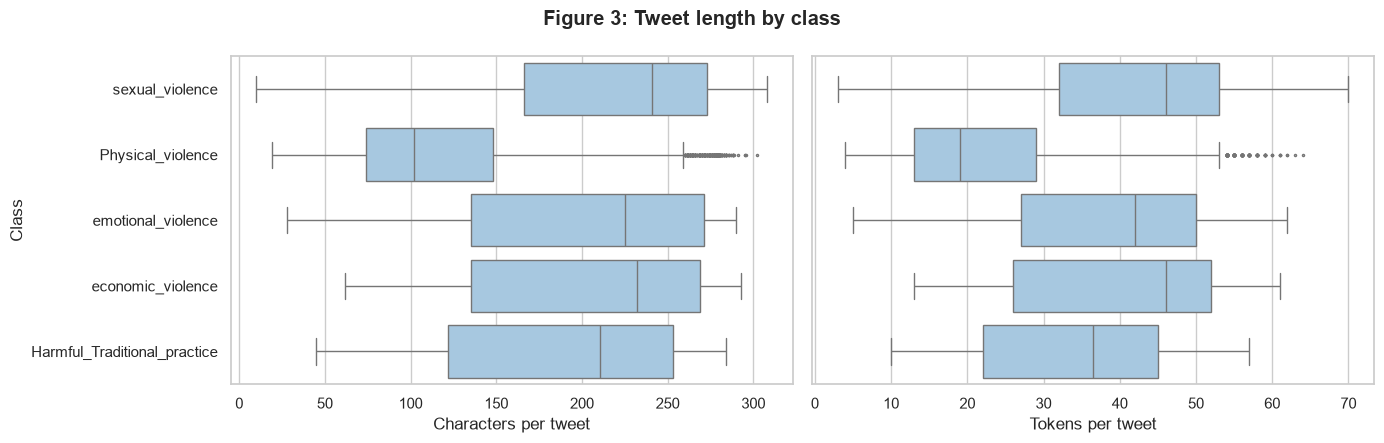

Suggested max sequence length (tokens) if truncating at a percentile of TRAIN tweets:
{'p90': 56, 'p95': 58, 'p99': 61, 'p100': 70}
Tweets longer than 280 characters: 3.37%


In [8]:
by_class = len_train.assign(cls=train[LABEL_COL].values)
class_len = by_class.groupby("cls")[["chars", "tokens"]].agg(["count", "mean", "median", "std"]).round(1).loc[CLASS_ORDER]
class_len.to_csv(METRICS / "eda_length_by_class.csv")
display(class_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, unit, xl in zip(axes, ["chars", "tokens"], ["Characters per tweet", "Tokens per tweet"]):
    sns.boxplot(data=by_class, x=unit, y="cls", order=CLASS_ORDER, ax=ax, color="#9ecae9", fliersize=1.5)
    ax.set_xlabel(xl); ax.set_ylabel("Class")
fig.suptitle("Figure 3: Tweet length by class", fontweight="bold")
fig.tight_layout(); save_fig(fig, "fig03_length_boxplot_by_class"); plt.show()

print("Suggested max sequence length (tokens) if truncating at a percentile of TRAIN tweets:")
print({f"p{p}": int(np.ceil(np.percentile(len_train['tokens'], p))) for p in (90, 95, 99, 100)})
print(f"Tweets longer than 280 characters: {(len_train['chars'] > 280).mean() * 100:.2f}%")

## 5. Vocabulary
Token statistics use a simple lower-cased alphanumeric tokenizer (`src/eda.py::tokenize`) *for description only*. The test out-of-vocabulary (OOV) rate shows how much unseen vocabulary the models will meet at inference. Class-distinctive tokens are listed only to understand the data; they are **not** used as classification rules (the challenge forbids keyword solutions).

In [9]:
cnt_train = eda.token_counts(train[TEXT_COL])
cnt_test = eda.token_counts(test[TEXT_COL])
vs = pd.Series(eda.vocab_stats(cnt_train, cnt_test), name="value").to_frame()
vs.to_csv(METRICS / "eda_vocab_stats.csv")
display(vs)
top = pd.DataFrame(cnt_train.most_common(25), columns=["token", "count"])
display(top.T)

,value
train tokens,1541114.00
train vocabulary size,38046.00
hapax (freq = 1),19152.00
hapax % of vocabulary,50.34
words with freq >= 5,9685.00
test vocabulary size,23823.00
test OOV token rate % (vs train vocab),2.40
test OOV types % (vs train vocab),35.92


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
token,me,he,i,to,and,the,raped,a,was,my,that,of,in,you,it,is,for,him,his,with,this,but,her,not,when
count,55091,50384,47810,38157,37867,36146,34300,34130,25703,25348,19403,17032,16359,15078,14735,14128,12178,10895,9715,9235,9221,8985,8351,8300,8090


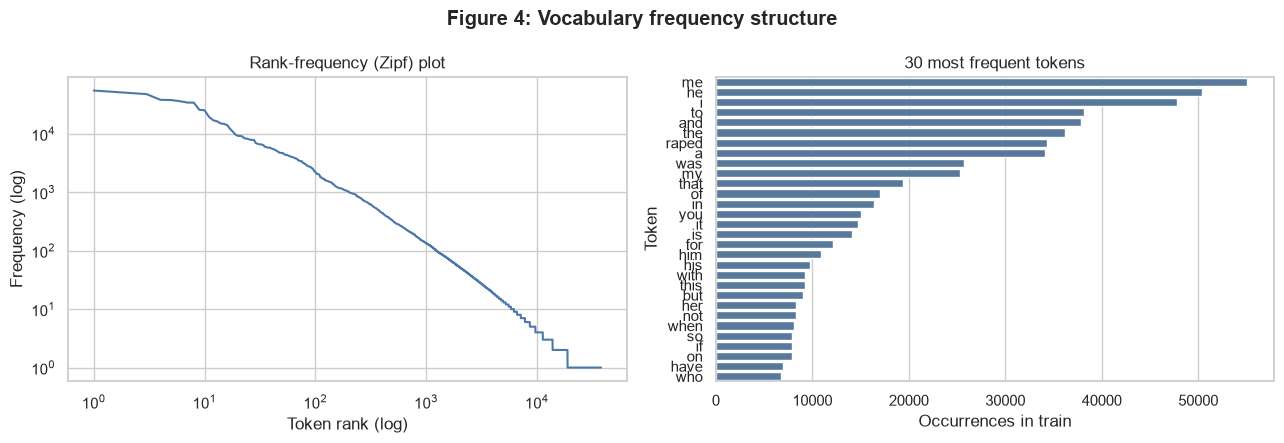

In [10]:
freqs = np.array(sorted(cnt_train.values(), reverse=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(np.arange(1, len(freqs) + 1), freqs, color="#4C78A8")
axes[0].set_xlabel("Token rank (log)"); axes[0].set_ylabel("Frequency (log)"); axes[0].set_title("Rank-frequency (Zipf) plot")
top30 = pd.DataFrame(cnt_train.most_common(30), columns=["token", "count"])
sns.barplot(data=top30, x="count", y="token", ax=axes[1], color="#4C78A8")
axes[1].set_xlabel("Occurrences in train"); axes[1].set_ylabel("Token"); axes[1].set_title("30 most frequent tokens")
fig.suptitle("Figure 4: Vocabulary frequency structure", fontweight="bold")
fig.tight_layout(); save_fig(fig, "fig04_vocabulary"); plt.show()

In [11]:
distinct = eda.distinctive_tokens(train, TEXT_COL, LABEL_COL, top_n=10, min_count=10)
distinct.to_csv(METRICS / "eda_class_distinctive_tokens.csv", index=False)
distinct.pivot(index="rank", columns="class", values="token")[CLASS_ORDER]

class,sexual_violence,Physical_violence,emotional_violence,economic_violence,Harmful_Traditional_practice
rank,,,,,
1,raped,beats,aam,fired,undergo
2,molested,headphones,mujhe,toy,mutilation
3,epstein,dissolve,sar,job,genital
4,defiled,housewife,humiliated,rough,shagufa
5,consensual,bose,insulted,boss,cameroon
6,tw,oladimeji,forum,store,fgm
7,proven,stupor,public,manager,afghanistan
8,jacob,aigbe,humiliation,jobs,originally
9,tara,planks,verbally,worker,marriage


## 6. Social-media noise
Prevalence (% of tweets with at least one occurrence) of hashtags, mentions, URLs, emojis, numbers, repeated characters, punctuation, non-ASCII characters and shouting (ALL-CAPS words), overall and per class. This tells us which preprocessing decisions can matter (see preprocessing experiments in notebook 02).

**Code-switching probe.** `swahili_probe_words` counts a small hand-written list of frequent Swahili/Sheng function words (`src/eda.py::SWAHILI_PROBE`). It is only an *indicative* probe — it is not language identification, and short words can be English typos or names — so a low or high value must not be read as proof of code-switching.

In [12]:
noise = eda.noise_features(train, TEXT_COL)
prev = eda.noise_prevalence(noise, train[LABEL_COL])[["all"] + CLASS_ORDER]
prev.to_csv(METRICS / "eda_noise_prevalence.csv")
display(prev)
print("Mean count per tweet:"); display(noise.mean().round(3).to_frame("mean per tweet").T)

,all,sexual_violence,Physical_violence,emotional_violence,economic_violence,Harmful_Traditional_practice
urls,0.01,0.01,0.02,0.00,0.00,0.00
mentions,0.00,0.00,0.00,0.00,0.00,0.00
hashtags,0.00,0.00,0.00,0.00,0.00,0.00
emojis,11.26,10.84,14.01,9.52,9.68,5.85
numbers,27.58,29.66,16.58,17.67,29.49,45.21
repeated_chars,25.37,23.29,37.32,19.20,23.50,31.91
punctuation,97.06,97.14,96.59,96.93,96.77,98.40
html_entities,8.32,8.80,5.72,8.76,5.53,8.51
typographic_quotes,32.28,34.46,21.90,20.58,33.18,20.21
retweet_marker,0.26,0.07,1.16,0.61,2.76,1.06


Mean count per tweet:


,urls,mentions,hashtags,emojis,numbers,repeated_chars,punctuation,html_entities,typographic_quotes,retweet_marker,non_ascii,all_caps_words,swahili_probe_words
mean per tweet,0.0,0.0,0.0,0.255,0.448,0.357,7.058,0.126,0.813,0.003,1.201,0.881,0.011


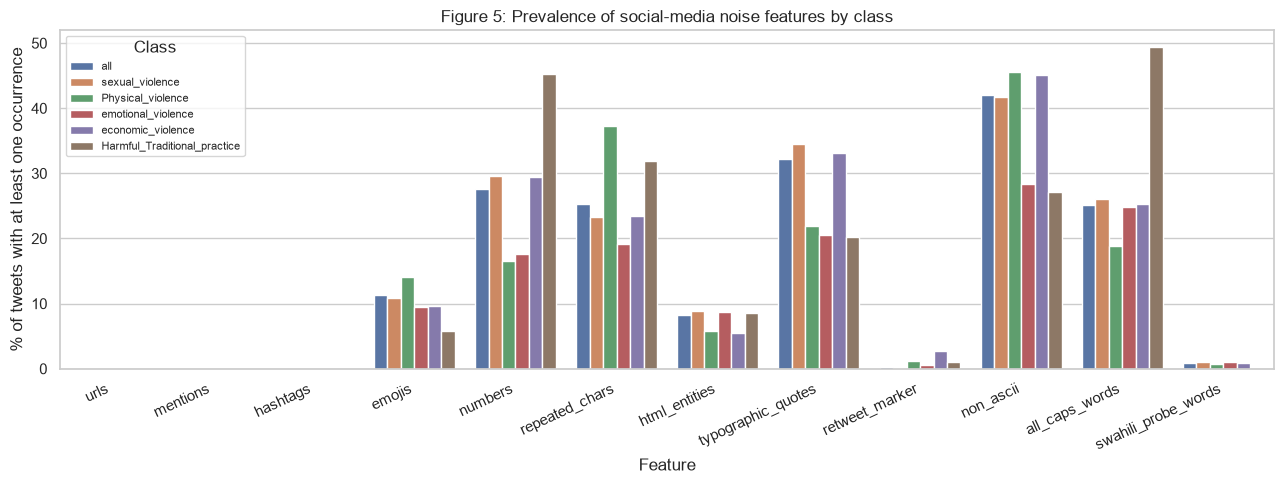

In [13]:
plot_df = prev.drop(index=["punctuation"]).reset_index().melt(id_vars="index", var_name="class", value_name="percent")
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=plot_df, x="index", y="percent", hue="class", hue_order=["all"] + CLASS_ORDER, ax=ax)
ax.set_xlabel("Feature"); ax.set_ylabel("% of tweets with at least one occurrence")
ax.set_title("Figure 5: Prevalence of social-media noise features by class")
ax.legend(title="Class", fontsize=8); plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
fig.tight_layout(); save_fig(fig, "fig05_noise_prevalence"); plt.show()

**Which non-ASCII characters are these?** The `non_ascii` feature is high, so we check whether it comes from emojis or from typographic punctuation (curly quotes, dashes) — this decides whether a normalisation step is worthwhile. Only characters and their Unicode names are shown.

In [14]:
na = eda.non_ascii_breakdown(train[TEXT_COL], top_n=12)
na.to_csv(METRICS / "eda_non_ascii_chars.csv", index=False)
na

,char,codepoint,name,count,distinct_non_ascii_chars
0,'’',U+2019,RIGHT SINGLE QUOTATION MARK,21154,875
1,'“',U+201C,LEFT DOUBLE QUOTATION MARK,5265,875
2,'”',U+201D,RIGHT DOUBLE QUOTATION MARK,5143,875
3,'😂',U+1F602,FACE WITH TEARS OF JOY,1107,875
4,'️',U+FE0F,VARIATION SELECTOR-16,956,875
5,'–',U+2013,EN DASH,892,875
6,'😭',U+1F62D,LOUDLY CRYING FACE,761,875
7,'‘',U+2018,LEFT SINGLE QUOTATION MARK,691,875
8,'\u200d',U+200D,ZERO WIDTH JOINER,547,875
9,'\xa0',U+00A0,NO-BREAK SPACE,403,875


## 7. Duplicates and near-duplicates
Exact duplicates are counted on raw text; near-duplicates use normalised text (lower-cased, whitespace collapsed). Duplicates split across train/validation would inflate scores, and duplicates with *different* labels reveal annotation noise.

In [15]:
exact_dups = int(train[TEXT_COL].duplicated().sum())
dup = eda.duplicate_report(train, test, TEXT_COL, LABEL_COL, duplicate_group_key)
dup = {"exact duplicate tweets (train, rows beyond first)": exact_dups, **dup}
dup_df = pd.Series(dup, name="value").to_frame()
dup_df.to_csv(METRICS / "eda_duplicates.csv")
dup_df

,value
"exact duplicate tweets (train, rows beyond first)",8
train rows in duplicate groups,887
duplicate groups,334
groups with conflicting labels,2
test tweets also present in train,10
duplicate tweets within test (beyond first),201


## 8. Shared train/validation split
`make_split` (in `src/data_loader.py`) produces the **only** split every model uses: an 80/20 stratified split with seed 42 in which all tweets with the same normalised text stay together (`StratifiedGroupKFold`). The assignment is saved to `results/metrics/split.csv` so it can be verified and reused.

In [16]:
train_df, val_df = make_split(train)
split_table = pd.concat([
    train_df[LABEL_COL].value_counts().rename("train_n"),
    val_df[LABEL_COL].value_counts().rename("val_n"),
], axis=1).loc[CLASS_ORDER]
split_table["train_%"] = (100 * split_table["train_n"] / split_table["train_n"].sum()).round(2)
split_table["val_%"] = (100 * split_table["val_n"] / split_table["val_n"].sum()).round(2)
split_table["full_%"] = dist["percent"]
display(split_table)

# leakage checks
assert set(train_df[ID_COL]).isdisjoint(val_df[ID_COL]), "ID overlap between train and validation"
overlap = set(train_df[TEXT_COL].map(duplicate_group_key)) & set(val_df[TEXT_COL].map(duplicate_group_key))
assert not overlap, "duplicate text shared between train and validation"
assert len(train_df) + len(val_df) == len(train)
print(f"train={len(train_df):,}  validation={len(val_df):,}  | duplicate text shared across split: {len(overlap)}")

split_ids = pd.concat([train_df[[ID_COL]].assign(split="train"), val_df[[ID_COL]].assign(split="val")])
split_ids.to_csv(METRICS / "split.csv", index=False)
split_table.to_csv(METRICS / "eda_split_summary.csv")

,train_n,val_n,train_%,val_%,full_%
type,,,,,
sexual_violence,26118,6530,82.34,82.34,82.34
Physical_violence,4756,1190,14.99,15.00,15.00
emotional_violence,521,130,1.64,1.64,1.64
economic_violence,174,43,0.55,0.54,0.55
Harmful_Traditional_practice,150,38,0.47,0.48,0.47


train=31,719  validation=7,931  | duplicate text shared across split: 0


## 9. Findings that feed the modelling decisions
Computed directly from the tables above (nothing typed by hand).

In [17]:
p = lambda s, q: int(np.ceil(np.percentile(s, q)))
minority = dist["count"].idxmin()
findings = {
    "train / test rows": f"{len(train):,} / {len(test):,}",
    "largest class share": f"{CLASS_ORDER[0]} = {dist['percent'].iloc[0]}%",
    "smallest class": f"{minority} = {dist['count'].min()} tweets ({dist['percent'].min()}%)",
    "majority-class accuracy baseline": f"{majority_acc:.2f}%",
    "tokens per tweet: median / p95 / p99 / max": f"{int(len_train['tokens'].median())} / {p(len_train['tokens'], 95)} / {p(len_train['tokens'], 99)} / {len_train['tokens'].max()}",
    "train vocabulary size": f"{len(cnt_train):,}",
    "test OOV token rate": f"{vs.loc['test OOV token rate % (vs train vocab)', 'value']}%",
    "near-duplicate rows in train": f"{dup['train rows in duplicate groups']} in {dup['duplicate groups']} groups ({dup['groups with conflicting labels']} with conflicting labels)",
    "test tweets also in train": dup["test tweets also present in train"],
}
pd.Series(findings, name="finding").to_frame()

,finding
train / test rows,"39,650 / 15,581"
largest class share,sexual_violence = 82.34%
smallest class,Harmful_Traditional_practice = 188 tweets (0.47%)
majority-class accuracy baseline,82.34%
tokens per tweet: median / p95 / p99 / max,43 / 58 / 61 / 70
train vocabulary size,"38,046"
test OOV token rate,2.4%
near-duplicate rows in train,887 in 334 groups (2 with conflicting labels)
test tweets also in train,10


### Interpretation of the results above
Each item is an **observation** (measured above) followed by what it **implies** for modelling. Implications are hypotheses to be tested in notebooks 02–07, not conclusions.

1. **Severe class imbalance.** `sexual_violence` is 82.34% of Train.csv, while `Harmful_Traditional_practice` (188 tweets, 0.47%) and `economic_violence` (217, 0.55%) are ~170x and ~150x smaller. A model that always predicts the majority class already scores 82.34% accuracy, so accuracy alone is uninformative. → **Macro-F1 is the primary metric**; accuracy is still reported for comparability with the challenge. Neural models will likely need class weighting or resampling, and the small classes give the validation set only 36–40 examples each, so per-class scores there will be noisy.
2. **Length differs strongly by class.** Physical-violence tweets are much shorter (median 19 tokens) than the others (median 37–47). Length may therefore be a partly class-informative signal; padding/truncation choices could affect classes unequally. → LSTM/CNN/TCN sequence length should be chosen with this in mind (tokens: p95 ≈ 59, p99 ≈ 62, max 70 — a length of ~64 keeps essentially all tweets untruncated).
3. **Tweets are short and bounded.** Max 308 characters, 70 tokens. Long-range dependencies are therefore limited to ~70 positions; any advantage of attention over recurrence for very long context cannot be expected to be large *a priori*.
4. **Large, sparse vocabulary.** ~38k types, about half of which occur once (hapax). Only ~2.4% of test *tokens* are out of the training vocabulary, but ~36% of test *types* are. → subword/pretrained tokenization (Transformer) and embedding sharing are worth comparing against word-level vocabularies; the TF-IDF baseline should use a minimum-frequency cutoff.
5. **The text is already largely stripped of Twitter markup.** No `@mentions` or `#hashtags` and only a handful of URLs. → The "remove URLs/mentions" (B) and "hashtag handling" (D) preprocessing experiments are expected to be near no-ops on this dataset; they will still be run and reported, and the outcome documented rather than assumed.
6. **Other noise is common and worth testing.** ~25% of tweets have repeated characters, ~8% contain HTML entities (`&amp;`), ~32% contain curly quotes/apostrophes, ~11% contain emojis, ~25% contain ALL-CAPS words (49% for `Harmful_Traditional_practice`), and numbers appear in 45% of `Harmful_Traditional_practice` tweets vs ~17% for physical/emotional. → Candidate preprocessing experiments: normalise typographic quotes/apostrophes, decode HTML entities, collapse repeated characters, keep vs remove emojis, keep vs lower-case. Whether these help is **NOT YET MEASURED**.
7. **Code-switching is not evidenced.** The Swahili/Sheng probe matches under 1% of tweets on average (0% in `Harmful_Traditional_practice`). This crude probe cannot exclude code-switching in other languages, but the data gives no support for treating the corpus as code-switched, so we do not claim it.
8. **Duplicates.** Only 8 exact duplicates, but after normalising case and whitespace 887 training rows fall in 334 duplicate groups, and 2 groups carry conflicting labels (evidence of some label noise). 10 test tweets also appear in train. → The split keeps duplicate groups together to avoid leakage, and near-duplicate content should be considered when reading validation scores.
9. **Distinctive tokens are descriptive only.** Class-specific tokens exist (see the table in section 5), but using them as rules would be a keyword solution, which the challenge disallows; they are reported to understand the data, not to classify it.

**Shared split (used by every notebook):** 31,719 train / 7,931 validation, stratified, seed 42, duplicate groups kept together; class proportions match the full training set to within ~0.2 percentage points. The assignment is stored in `results/metrics/split.csv`.